In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
string_d256 = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/STRING_EXP_d256.tsv', sep='\t')
string_d256


,gene_id,node2vec_STRING_EXP_0,node2vec_STRING_EXP_1,node2vec_STRING_EXP_2,node2vec_STRING_EXP_3,node2vec_STRING_EXP_4,node2vec_STRING_EXP_5,node2vec_STRING_EXP_6,node2vec_STRING_EXP_7,node2vec_STRING_EXP_8,...,verse_STRING_EXP_246,verse_STRING_EXP_247,verse_STRING_EXP_248,verse_STRING_EXP_249,verse_STRING_EXP_250,verse_STRING_EXP_251,verse_STRING_EXP_252,verse_STRING_EXP_253,verse_STRING_EXP_254,verse_STRING_EXP_255
0,ENSG00000000003,-0.158329,0.008308,0.118519,-0.087278,0.313145,0.215767,0.048669,0.268924,-0.063683,...,-0.329438,-0.538497,0.140982,0.295603,0.604602,0.175698,0.062513,0.086692,0.208025,0.003071
1,ENSG00000000005,-0.162750,0.052371,0.178036,-0.092080,0.307798,0.256712,0.001573,0.118733,-0.056287,...,-0.174400,0.222089,-0.018087,0.443203,0.412000,0.537673,-0.003016,0.335867,0.278030,-0.183193
2,ENSG00000000419,-0.058800,0.002659,0.173786,-0.055411,0.279645,-0.033252,-0.031629,0.112735,0.042836,...,-0.192480,-0.483663,0.034511,0.216154,0.058332,0.217123,0.098323,-0.223368,0.118620,-0.261237
3,ENSG00000000457,-0.025679,-0.145224,0.209271,0.119755,0.277165,0.176383,0.021910,0.217870,-0.093987,...,-0.249385,-0.521057,0.020900,0.113873,-0.110502,0.260303,0.009650,-0.137390,0.663150,-0.154939
4,ENSG00000000460,-0.069898,0.275972,0.180736,-0.004726,0.184375,0.036563,0.019529,0.088202,0.086346,...,0.154351,-0.603756,0.009854,0.648571,-0.151773,0.393791,0.295855,0.091423,0.401832,-0.024769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18706,ENSG00000279911,-0.598471,0.382811,-0.039169,0.183706,0.686537,0.176689,-0.427945,0.272258,0.052865,...,-0.173007,-0.446800,-0.337107,0.135035,0.042456,-0.055865,0.457619,0.003182,0.681120,-0.031607
18707,ENSG00000279941,-0.601539,0.450953,0.028649,0.127208,0.694103,0.189831,-0.383279,0.337495,0.020672,...,0.050754,-0.221952,-0.134895,0.393986,-0.050678,-0.257727,0.444047,0.041466,0.648540,0.000061
18708,ENSG00000279973,-0.082818,0.027733,0.292972,-0.028230,0.228193,0.178925,-0.010238,0.082909,-0.046724,...,0.023862,-0.415215,-0.002750,-0.111985,0.104958,0.110743,-0.189555,-0.092775,0.662971,0.014086
18709,ENSG00000280165,-0.215868,0.028642,0.080562,-0.168185,0.147767,0.218426,-0.038098,0.024647,0.020232,...,0.062860,-0.325717,0.117232,0.420056,0.269431,0.291554,0.550628,0.326393,0.198189,0.156846


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
NCG_Known_Genes = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = string_d256.merge(NCG_Known_Genes, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,node2vec_STRING_EXP_0,node2vec_STRING_EXP_1,node2vec_STRING_EXP_2,node2vec_STRING_EXP_3,node2vec_STRING_EXP_4,node2vec_STRING_EXP_5,node2vec_STRING_EXP_6,node2vec_STRING_EXP_7,node2vec_STRING_EXP_8,node2vec_STRING_EXP_9,...,verse_STRING_EXP_250,verse_STRING_EXP_251,verse_STRING_EXP_252,verse_STRING_EXP_253,verse_STRING_EXP_254,verse_STRING_EXP_255,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,-0.158329,0.008308,0.118519,-0.087278,0.313145,0.215767,0.048669,0.268924,-0.063683,0.021854,...,0.604602,0.175698,0.062513,0.086692,0.208025,0.003071,False,False,False,False
ENSG00000000005,-0.162750,0.052371,0.178036,-0.092080,0.307798,0.256712,0.001573,0.118733,-0.056287,0.094436,...,0.412000,0.537673,-0.003016,0.335867,0.278030,-0.183193,False,False,False,False
ENSG00000000419,-0.058800,0.002659,0.173786,-0.055411,0.279645,-0.033252,-0.031629,0.112735,0.042836,-0.129551,...,0.058332,0.217123,0.098323,-0.223368,0.118620,-0.261237,False,False,False,False
ENSG00000000457,-0.025679,-0.145224,0.209271,0.119755,0.277165,0.176383,0.021910,0.217870,-0.093987,0.019938,...,-0.110502,0.260303,0.009650,-0.137390,0.663150,-0.154939,False,False,False,False
ENSG00000000938,-0.365956,-0.112647,0.169030,0.171834,0.325265,0.047035,-0.152173,0.391414,0.052677,0.062963,...,-0.178556,0.049830,0.066524,0.396366,0.663410,-0.009349,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278129,-0.092017,0.055001,0.295257,-0.068709,0.248391,0.156621,-0.042240,0.140015,-0.033668,-0.068853,...,0.057306,0.793601,-0.100183,0.075729,0.312260,0.119610,False,False,False,False
ENSG00000278195,-0.273537,-0.066660,0.106216,-0.180886,0.143768,0.151087,0.006613,0.044997,-0.027584,0.037608,...,-0.189062,0.199442,-0.183814,0.420074,0.102433,0.000785,False,False,False,False
ENSG00000278259,0.029912,0.072592,-0.049013,-0.088473,0.400912,-0.001679,0.014559,0.141810,-0.084123,-0.017858,...,0.140090,0.231413,0.252486,0.207821,0.507548,-0.138220,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    12280
True       628
Name: count, dtype: int64

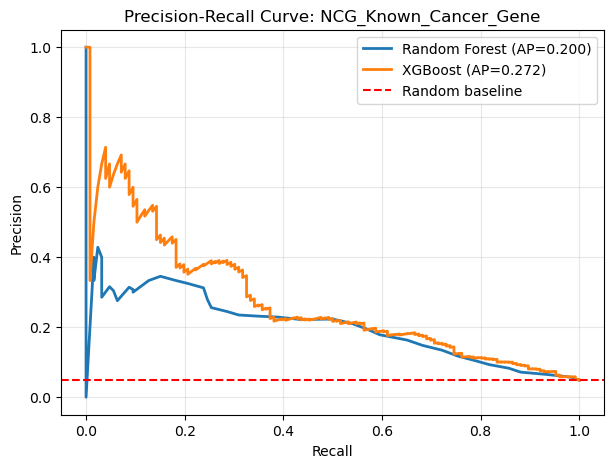

Random Forest - auPRC: 0.200
XGBoost - auPRC: 0.272



In [6]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11690
True      1218
Name: count, dtype: int64

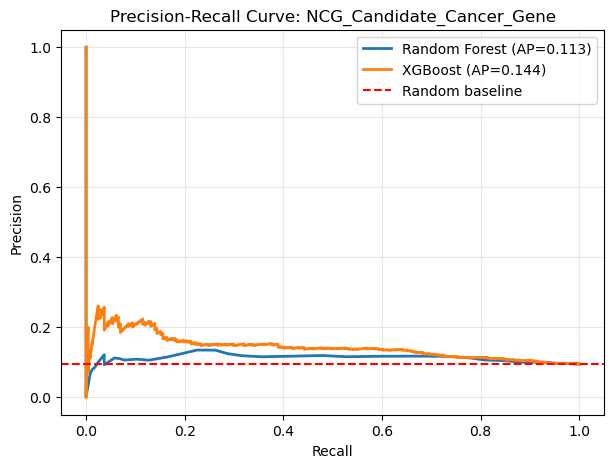

Random Forest - auPRC: 0.113
XGBoost - auPRC: 0.144



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    12412
True       496
Name: count, dtype: int64

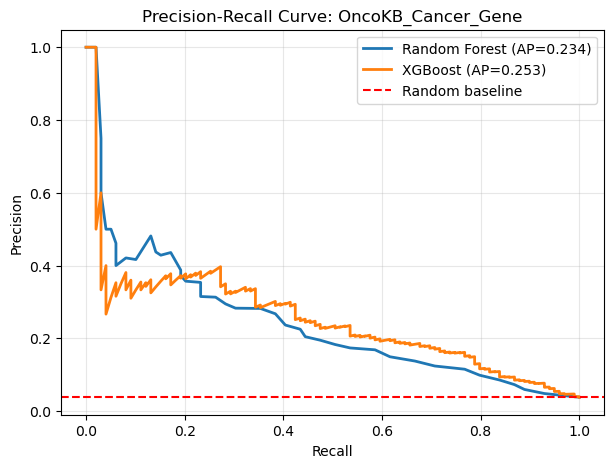

Random Forest - auPRC: 0.234
XGBoost - auPRC: 0.253



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12640
True       268
Name: count, dtype: int64

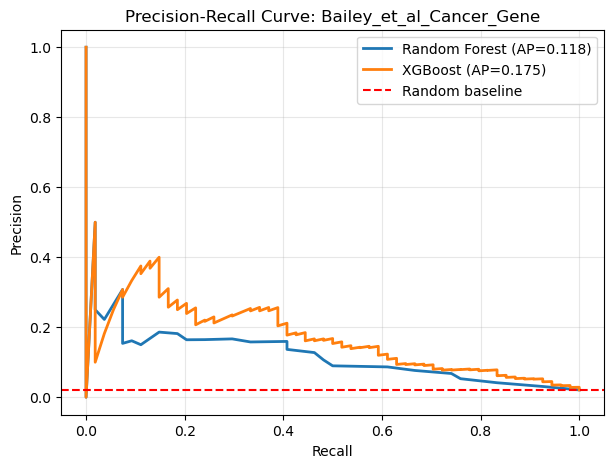

Random Forest - auPRC: 0.118
XGBoost - auPRC: 0.175



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')